## Importando as bibliotecas e analisando a  base de dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv(r'C:\Users\User\Documents\data_science_Alura\Data_Science_Alura\desafio TelecomX-2\df_tratado.csv')

In [3]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 


In [5]:
df.iloc[0]

customerID            0002-ORFBO
Churn                         No
gender                    Female
SeniorCitizen                  0
Partner                      Yes
Dependents                   Yes
tenure                         9
PhoneService                 Yes
MultipleLines                 No
InternetService              DSL
OnlineSecurity                No
OnlineBackup                 Yes
DeviceProtection              No
TechSupport                  Yes
StreamingTV                  Yes
StreamingMovies               No
Contract                One year
PaperlessBilling             Yes
PaymentMethod       Mailed check
Charges.Monthly             65.6
Charges.Total              593.3
Contas_Diarias          2.186667
Name: 0, dtype: object

## Excluindo colunas desnecessárias e fazendo as modificações necessárias

In [6]:
df = df.drop(columns = ['customerID'])

In [7]:
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})
df['Partner'] = df['Partner'].replace({'No': 0, 'Yes': 1})
df['Dependents'] = df['Dependents'].replace({'No': 0, 'Yes': 1})
df['PhoneService'] = df['PhoneService'].replace({'No': 0, 'Yes': 1})
df['PaperlessBilling'] = df['PaperlessBilling'].replace({'No': 0, 'Yes': 1})

C:\Users\User\AppData\Local\Temp\ipykernel_2688\2303187439.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})
C:\Users\User\AppData\Local\Temp\ipykernel_2688\2303187439.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Partner'] = df['Partner'].replace({'No': 0, 'Yes': 1})
C:\Users\User\AppData\Local\Temp\ipykernel_2688\2303187439.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, exp

In [8]:
df['gender'] = df['gender'].replace({'Female': 0, 'Male':1})

C:\Users\User\AppData\Local\Temp\ipykernel_2688\366069728.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Female': 0, 'Male':1})


In [9]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

In [10]:
df.iloc[0]

Churn                          0
gender                         0
SeniorCitizen                  0
Partner                        1
Dependents                     1
tenure                         9
PhoneService                   1
MultipleLines                 No
InternetService              DSL
OnlineSecurity                No
OnlineBackup                 Yes
DeviceProtection              No
TechSupport                  Yes
StreamingTV                  Yes
StreamingMovies               No
Contract                One year
PaperlessBilling               1
PaymentMethod       Mailed check
Charges.Monthly             65.6
Charges.Total              593.3
Contas_Diarias          2.186667
Name: 0, dtype: object

## Transformando variáveis categóricas com One Hot Encoder

In [11]:
variaveis_categoricas = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

In [12]:
one_hot_enc = make_column_transformer((OneHotEncoder(handle_unknown='ignore'), variaveis_categoricas), remainder='passthrough')

df_encoded = one_hot_enc.fit_transform(df)
df_encoded = pd.DataFrame(df_encoded, columns=one_hot_enc.get_feature_names_out())
df_encoded

,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_No,onehotencoder__OnlineSecurity_No internet service,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_No,...,remainder__gender,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__PaperlessBilling,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Contas_Diarias
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,9.0,1.0,1.0,65.60,593.30,2.186667
1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,9.0,1.0,0.0,59.90,542.40,1.996667
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,4.0,1.0,1.0,73.90,280.85,2.463333
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,13.0,1.0,1.0,98.00,1237.85,3.266667
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,3.0,1.0,1.0,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,13.0,1.0,0.0,55.15,742.90,1.838333
7028,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,22.0,1.0,1.0,85.10,1873.70,2.836667
7029,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,2.0,1.0,1.0,50.30,92.75,1.676667
7030,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,1.0,67.0,1.0,0.0,67.85,4627.65,2.261667


Nesta etapa transformei colunas com valores Yes or No para colunas com 1 e 0, respectivamente. Além disso, transformei as variáveis categóricas em variáveis numéricas com o One Hot Encoder

## Verificando a proporção da evasão 

In [14]:
df_encoded['remainder__Churn'].value_counts(normalize=True)

remainder__Churn
0.0    0.734215
1.0    0.265785
Name: proportion, dtype: float64

## Normalização das colunas de gasto

In [16]:
scaler = MinMaxScaler()
df_normalizado = scaler.fit_transform(df_encoded)


In [17]:
df_normalizado = pd.DataFrame(df_normalizado, columns= df_encoded.columns)

In [18]:
df_normalizado.head()

,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_No,onehotencoder__OnlineSecurity_No internet service,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_No,...,remainder__gender,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__PaperlessBilling,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Contas_Diarias
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.112676,1.0,1.0,0.471144,0.066294,0.471144
1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.112676,1.0,0.0,0.414428,0.060420,0.414428
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.042254,1.0,1.0,0.553731,0.030239,0.553731
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.169014,1.0,1.0,0.793532,0.140670,0.793532
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.028169,1.0,1.0,0.653234,0.028687,0.653234


## Matriz de correlação

<Axes: >

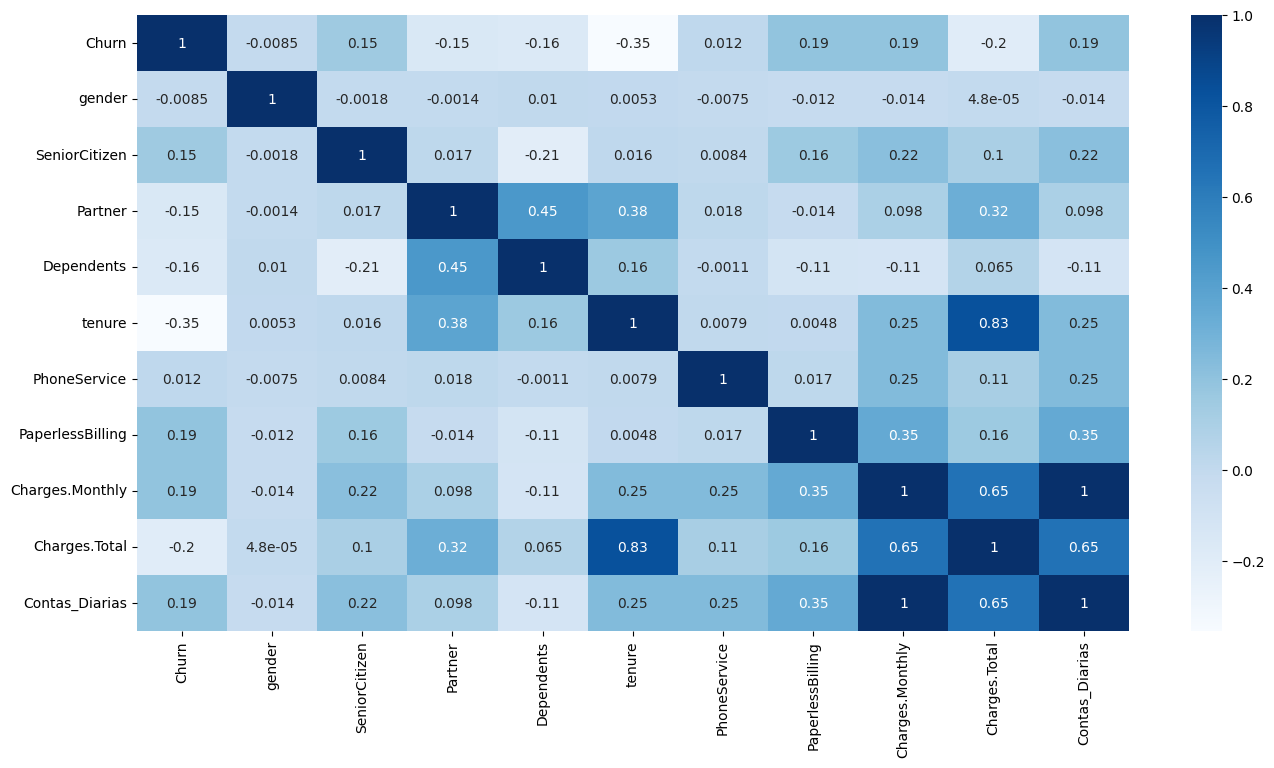

In [21]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(16,8))
sns.heatmap(corr, annot=True, cmap='Blues')

<Axes: >

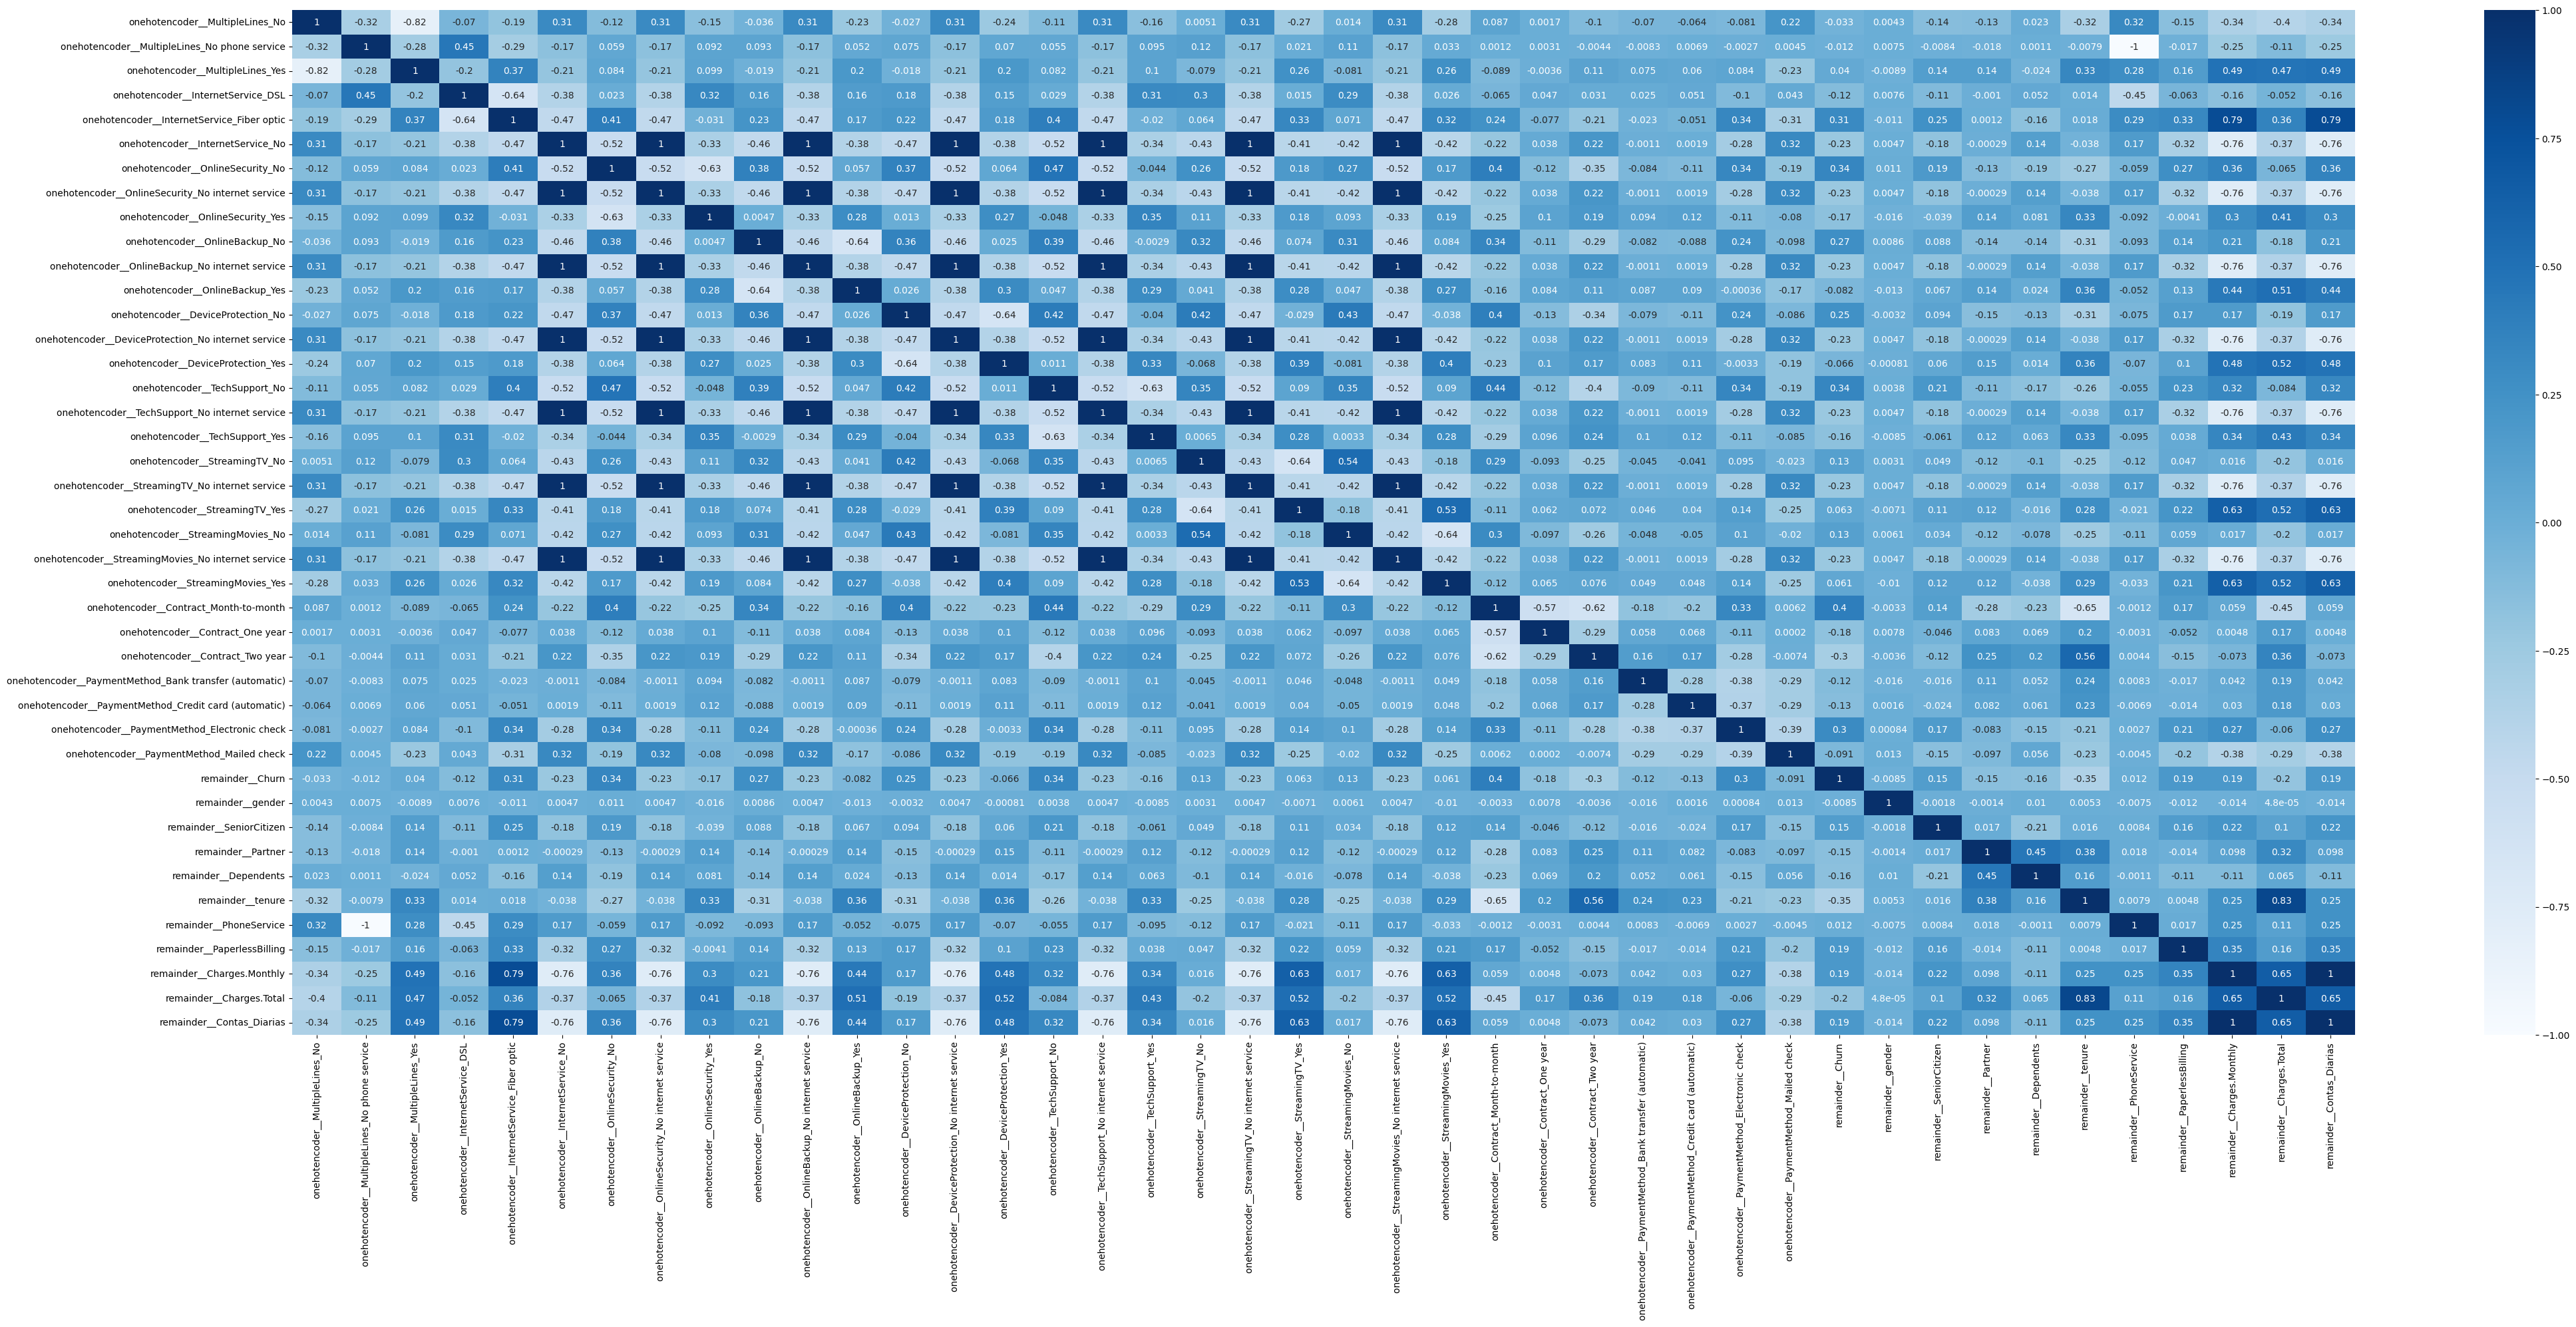

In [22]:
corr = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(50,20))
sns.heatmap(corr, annot=True, cmap='Blues')

In [23]:
df_encoded.columns

Index(['onehotencoder__MultipleLines_No',
       'onehotencoder__MultipleLines_No phone service',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No', 'onehotencoder__OnlineSecurity_No',
       'onehotencoder__OnlineSecurity_No internet service',
       'onehotencoder__OnlineSecurity_Yes', 'onehotencoder__OnlineBackup_No',
       'onehotencoder__OnlineBackup_No internet service',
       'onehotencoder__OnlineBackup_Yes', 'onehotencoder__DeviceProtection_No',
       'onehotencoder__DeviceProtection_No internet service',
       'onehotencoder__DeviceProtection_Yes', 'onehotencoder__TechSupport_No',
       'onehotencoder__TechSupport_No internet service',
       'onehotencoder__TechSupport_Yes', 'onehotencoder__StreamingTV_No',
       'onehotencoder__StreamingTV_No internet service',
       'onehotencoder__StreamingTV_Yes', 'onehotencoder__StreamingMovies_No'

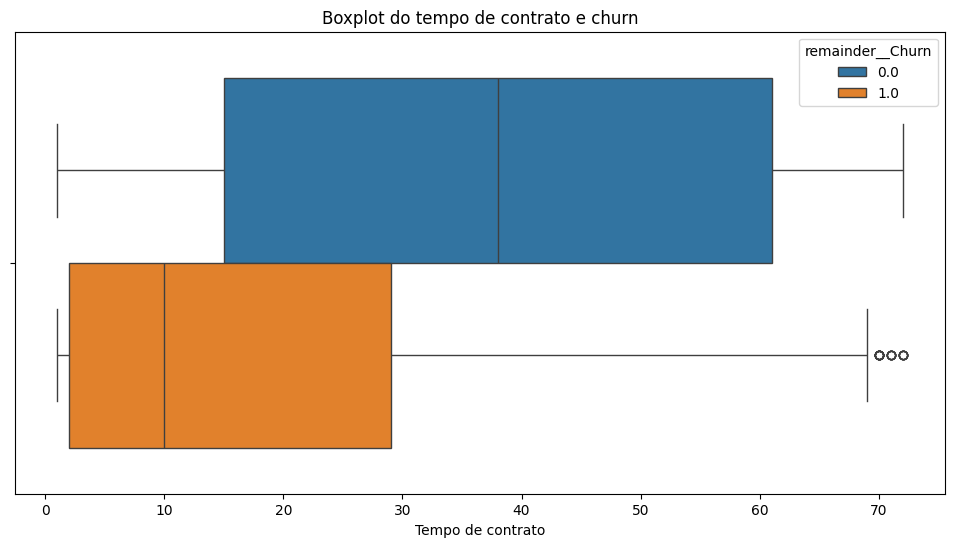

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(data = df_encoded, x = 'remainder__tenure', hue='remainder__Churn')
plt.xlabel('Tempo de contrato')
plt.title('Boxplot do tempo de contrato e churn')
plt.show()

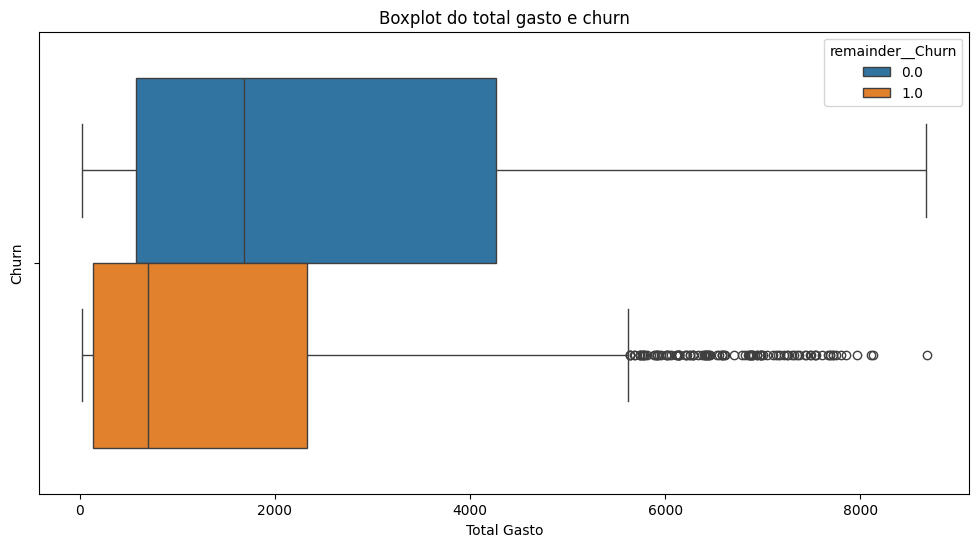

In [38]:
plt.figure(figsize=(12, 6))
sns.boxplot(data = df_encoded, x = 'remainder__Charges.Total', hue='remainder__Churn')
plt.xlabel('Total Gasto')
plt.ylabel('Churn')
plt.title('Boxplot do total gasto e churn')
plt.show()